## 0. Setup

In [1]:
import os
import time
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 1. Finland Population Data
Downloads raw demographic data from [Statistics Finland's StatFin API](https://pxdata.stat.fi/PxWeb/pxweb/en/StatFin/) and combines it into a single `population_overview.csv`.

**Sources (CC BY 4.0)**
| Dataset | Table |
|---|---|
| Population structure | `statfin_vaerak_pxt_11rd.px` |
| Births | `statfin_synt_pxt_12dr.px` |
| Fertility rate | `statfin_synt_pxt_12dt.px` |
| Deaths | `statfin_kuol_pxt_12af.px` |
| Migration | `statfin_muutl_pxt_11a8.px` |
| Population by area | `statfin_vaerak_pxt_11ra.px` |

**Outputs:**
- `./data/population_overview.csv` — one row per year: `Year, population, births, deaths, natural_change, immigration, emigration, net_migration, total_change, tfr`
- `./data/population_by_area_long.csv` — one row per area/year: `Area, Year, population, share_under_15_pct, share_15_64_pct, share_over_65_pct, population_density, share_urban_pct, avg_age_total, avg_age_men, avg_age_women`

### 1.2 Configuration

In [2]:
BASE_URL   = "https://pxdata.stat.fi/PxWeb/api/v1/en/StatFin"
DATA_DIR   = "./data"       # raw CSVs
OUTPUT_DIR = "./data"       # population_overview.csv

os.makedirs(DATA_DIR, exist_ok=True)
print(f"Data directory: {os.path.abspath(DATA_DIR)}")

Data directory: c:\Reps\Spring2026\ML_task\data


### 1.3 Download helpers

In [3]:
def get_metadata(table_path):
    """GET variable/value metadata for a table."""
    r = requests.get(f"{BASE_URL}/{table_path}", timeout=30)
    r.raise_for_status()
    return r.json()


def _post_query(table_path, query, retries=5):
    """POST a query and return a DataFrame. Retries on 429 rate limit."""
    url  = f"{BASE_URL}/{table_path}"
    body = {"query": query, "response": {"format": "csv"}}
    for attempt in range(retries):
        r = requests.post(url, json=body, timeout=60)
        if r.status_code == 429:
            wait = 10 * (attempt + 1)
            print(f"  ⏳ Rate limited — waiting {wait}s (attempt {attempt+1}/{retries})")
            time.sleep(wait)
            continue
        r.raise_for_status()
        return pd.read_csv(StringIO(r.text))
    raise RuntimeError(f"Still rate limited after {retries} attempts. URL: {url}")


def fetch_table(table_path):
    """Fetch a full table, splitting by year if too large for one request."""
    meta  = get_metadata(table_path)
    query = [
        {"code": v["code"], "selection": {"filter": "all", "values": ["*"]}}
        for v in meta["variables"]
    ]
    try:
        return _post_query(table_path, query)
    except Exception:
        pass

    print("  ⚠ Too large — splitting by year")
    year_var = next(
        (v for v in meta["variables"]
         if v["code"].lower() in ("vuosi", "year") or "year" in v["text"].lower()),
        None,
    )
    if year_var is None:
        raise RuntimeError("Can't find year variable to split on.")
    chunks = []
    for year in year_var["values"]:
        q = []
        for v in meta["variables"]:
            if v["code"] == year_var["code"]:
                q.append({"code": v["code"], "selection": {"filter": "item", "values": [year]}})
            else:
                q.append({"code": v["code"], "selection": {"filter": "all", "values": ["*"]}})
        chunks.append(_post_query(table_path, q))
        time.sleep(1)
    return pd.concat(chunks, ignore_index=True)


print("Download helpers ready.")

Download helpers ready.


### 1.4 Download raw datasets
Each cell fetches one dataset and saves it to `./data/`. Re-run individual cells to refresh a specific file.

In [4]:
# Population structure
print("Fetching: population_structure")
df = fetch_table("vaerak/statfin_vaerak_pxt_11rd.px")
df.to_csv(f"{DATA_DIR}/population_structure.csv", index=False)
print(f"{len(df):,} rows, {len(df.columns)} cols")
df.head(3)

Fetching: population_structure
54 rows, 343 cols


,Year,Total Total Population 31 Dec,Total 0 Population 31 Dec,Total 1 Population 31 Dec,Total 2 Population 31 Dec,Total 3 Population 31 Dec,Total 4 Population 31 Dec,Total 5 Population 31 Dec,Total 6 Population 31 Dec,Total 7 Population 31 Dec,...,Females 103 Population 31 Dec,Females 104 Population 31 Dec,Females 105 Population 31 Dec,Females 106 Population 31 Dec,Females 107 Population 31 Dec,Females 108 Population 31 Dec,Females 109 Population 31 Dec,Females 110 Population 31 Dec,Females 111 Population 31 Dec,Females 112 Population 31 Dec
0,1972,4653401,58356,60628,61736,64379,69764,72672,73427,74070,...,2,0,1,0,0,0,0,0,0,0
1,1973,4678761,56312,58531,60865,62110,64681,70064,72976,73757,...,4,1,0,1,0,0,0,0,0,0
2,1974,4702387,62649,56385,58623,60998,62308,64789,70153,73107,...,1,1,0,0,1,0,0,0,0,0


In [5]:
# Births
print("Fetching: births")
df = fetch_table("synt/statfin_synt_pxt_12dr.px")
df.to_csv(f"{DATA_DIR}/births.csv", index=False)
print(f"{len(df):,} rows, {len(df.columns)} cols")
df.head(3)

Fetching: births
275 rows, 5 cols


,Year,"Crude birth rate, per mille",Boys per 1 000 girls,Live births,Mean population
0,1751,44.3,1018,18850,425700.0
1,1752,44.7,1008,19395,433750.0
2,1753,44.1,1011,19472,441450.0


In [6]:
# Fertility rate
print("Fetching: fertility_rate")
df = fetch_table("synt/statfin_synt_pxt_12dt.px")
df.to_csv(f"{DATA_DIR}/fertility_rate.csv", index=False)
print(f"{len(df):,} rows, {len(df.columns)} cols")
df.head(3)

Fetching: fertility_rate
250 rows, 2 cols


,Year,Total fertility rate
0,1776,5.42
1,1777,5.51
2,1778,5.82


In [7]:
# Deaths
print("Fetching: deaths")
df = fetch_table("kuol/statfin_kuol_pxt_12af.px")
df.to_csv(f"{DATA_DIR}/deaths.csv", index=False)
print(f"{len(df):,} rows, {len(df.columns)} cols")
df.head(3)

Fetching: deaths
275 rows, 4 cols


,Year,Total Deaths,Males Deaths,Females Deaths
0,1751,10475,5149,5326
1,1752,11400,5702,5698
2,1753,11502,5605,5897


In [8]:
# Migration — totals only (SSS = all combined), no nationality/language/sex breakdown
print("Fetching: migration (totals only)")
path = "muutl/statfin_muutl_pxt_11a8.px"
meta = get_metadata(path)
query = []
for v in meta["variables"]:
    code = v["code"].lower()
    if code in ("vuosi", "year"):
        query.append({"code": v["code"], "selection": {"filter": "all", "values": ["*"]}})
    elif code in ("kansalaisuus", "kieli", "syntyperä", "sukupuoli"):
        query.append({"code": v["code"], "selection": {"filter": "item", "values": ["SSS"]}})
    else:
        query.append({"code": v["code"], "selection": {"filter": "all", "values": ["*"]}})
df = _post_query(path, query)
df.to_csv(f"{DATA_DIR}/migration.csv", index=False)
print(f"{len(df):,} rows, {len(df.columns)} cols")
df.head(3)

Fetching: migration (totals only)
35 rows, 5 cols


,Year,Nationality,Total Total Total Immigration to Finland,Total Total Total Emigration from Finland,Total Total Total Net migration
0,1990,TOTAL,13558,6477,7081
1,1991,TOTAL,19001,5984,13017
2,1992,TOTAL,14554,6055,8499


In [9]:
# Population by area — 9 key metrics only, split by year to stay under cell limit
print("Fetching: population_by_area (filtered)")
KEEP_CODES = [
    "vaesto",             # Population 31 Dec
    "vaesto_alle15_p",    # Share aged under 15, %
    "vaesto_15_64_p",     # Share aged 15 to 64, %
    "vaesto_yli64_p",     # Share aged 65 or over, %
    "vaesto_maa_pa",      # Population density
    "vaesto_ks_p",        # Share in urban areas, %
    "vaesto_keski_ika",   # Average age, both sexes
    "vaesto_keski_ika_1", # Average age, men
    "vaesto_keski_ika_2", # Average age, women
]
path = "vaerak/statfin_vaerak_pxt_11ra.px"
meta = get_metadata(path)
info_var = next(v for v in meta["variables"] if v["code"].lower() == "tiedot")
year_var = next(
    v for v in meta["variables"]
    if v["code"].lower() in ("vuosi", "year") or "year" in v["text"].lower()
)
print(f"  {len(KEEP_CODES)} of {len(info_var['values'])} info codes, splitting across {len(year_var['values'])} years")
chunks = []
total  = len(year_var["values"])
for i, year in enumerate(year_var["values"]):
    query = []
    for v in meta["variables"]:
        if v["code"] == info_var["code"]:
            query.append({"code": v["code"], "selection": {"filter": "item", "values": KEEP_CODES}})
        elif v["code"] == year_var["code"]:
            query.append({"code": v["code"], "selection": {"filter": "item", "values": [year]}})
        else:
            query.append({"code": v["code"], "selection": {"filter": "all", "values": ["*"]}})
    chunks.append(_post_query(path, query))
    if (i + 1) % 5 == 0:
        print(f"  Progress: {i+1}/{total} years")
    time.sleep(1)
df = pd.concat(chunks, ignore_index=True)
df.to_csv(f"{DATA_DIR}/population_by_area.csv", index=False)
print(f"{len(df):,} rows, {len(df.columns)} cols")
df.head(3)

Fetching: population_by_area (filtered)
  9 of 43 info codes, splitting across 36 years
  Progress: 5/36 years
  Progress: 10/36 years
  Progress: 15/36 years
  Progress: 20/36 years
  Progress: 25/36 years
  Progress: 30/36 years
  Progress: 35/36 years
184,032 rows, 38 cols


,Area,Information,1990,1991,1992,1993,1994,1995,1996,1997,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,WHOLE COUNTRY,Population 31 Dec,4998478.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WHOLE COUNTRY,"Share of persons aged under 15, %",19.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,WHOLE COUNTRY,"Share of persons aged 15 to 64, %",67.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Reshape population_by_area → wide format: one row per Area/Year, one column per metric
print("Reshaping population_by_area…")
RENAME = {
    "Population 31 Dec":                   "population",
    "Share of persons aged under 15, %":   "share_under_15_pct",
    "Share of persons aged 15 to 64, %":   "share_15_64_pct",
    "Share of persons aged 65 or over, %": "share_over_65_pct",
    "Population density":                   "population_density",
    "Share of persons in urban areas, %":   "share_urban_pct",
    "Average age, both sexes":              "avg_age_total",
    "Average age, men":                     "avg_age_men",
    "Average age, women":                   "avg_age_women",
}
raw_area = pd.read_csv(f"{DATA_DIR}/population_by_area.csv", low_memory=False)
df_long  = raw_area.melt(id_vars=["Area", "Information"], var_name="Year", value_name="Value")
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long  = df_long.dropna(subset=["Value"])
df_long["Year"]        = df_long["Year"].astype(int)
df_long["Information"] = df_long["Information"].map(RENAME)
df_long  = df_long.dropna(subset=["Information"])
df_wide  = df_long.pivot_table(
    index=["Area", "Year"], columns="Information", values="Value"
).reset_index()
df_wide.columns.name = None
df_wide = df_wide.sort_values(["Area", "Year"]).reset_index(drop=True)
out_path = f"{DATA_DIR}/population_by_area_long.csv"
df_wide.to_csv(out_path, index=False)
print(f"{len(df_wide):,} rows, {len(df_wide.columns)} cols\n{out_path}")
df_wide.head(5)

Reshaping population_by_area…
20,448 rows, 11 cols
./data/population_by_area_long.csv


,Area,Year,avg_age_men,avg_age_total,avg_age_women,population,population_density,share_15_64_pct,share_over_65_pct,share_under_15_pct,share_urban_pct
0,Akaa,1990,36.3,38.6,40.8,16048.0,54.8,65.7,15.8,18.5,2.2
1,Akaa,1991,36.6,38.8,41.0,16096.0,54.9,65.5,16.1,18.5,2.3
2,Akaa,1992,36.6,38.8,40.9,16201.0,55.3,65.2,16.0,18.8,2.4
3,Akaa,1993,37.0,39.1,41.1,16142.0,55.1,65.0,16.4,18.6,2.5
4,Akaa,1994,37.2,39.3,41.3,16038.0,54.7,64.4,16.7,18.9,2.6


### 1.5 Combine helpers
Column-name detection handles both Finnish and English StatFin headers.

In [11]:
def _find_col(df, candidates, label):
    """Return the first matching column name (case-insensitive, with fuzzy fallback)."""
    lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    for cand in candidates:
        for col_lower, col in lower.items():
            if cand.lower() in col_lower:
                return col
    print(f"Could not find column for '{label}'. "
          f"Tried: {candidates}\n  Available: {df.columns.tolist()}")
    return None

def find_year_col(df):
    return _find_col(df, ["Year", "Vuosi", "year", "vuosi"], "Year")


def load_csv(filename):
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Not found: {path}  (skipping)")
        return None
    df = pd.read_csv(path, low_memory=False)
    print(f"{filename}: {len(df):,} rows, {len(df.columns)} cols")
    return df


def agg_births(df):
    yr  = find_year_col(df)
    val = _find_col(df, ["Live births", "Births", "live_births", "births",
                          "Elävänä syntyneet", "Syntyneet"], "births")
    if not yr or not val: return None
    df[val] = pd.to_numeric(df[val], errors="coerce")
    out = df.groupby(yr, as_index=False)[val].sum().rename(columns={yr: "Year", val: "births"})
    out["Year"] = out["Year"].astype(int)
    return out


def agg_deaths(df):
    yr  = find_year_col(df)
    val = _find_col(df, ["Deaths", "deaths", "Kuolleet", "Kuolemat"], "deaths")
    if not yr or not val: return None
    df[val] = pd.to_numeric(df[val], errors="coerce")
    out = df.groupby(yr, as_index=False)[val].sum().rename(columns={yr: "Year", val: "deaths"})
    out["Year"] = out["Year"].astype(int)
    return out


def agg_fertility(df):
    yr  = find_year_col(df)
    tfr = _find_col(df, ["Total fertility rate", "TFR", "tfr",
                          "Kokonaishedelmällisyys", "Fertility rate", "fertility_rate"], "TFR")
    if not tfr:
        others = [c for c in df.select_dtypes(include="number").columns if c != yr]
        if not others:
            print("Could not identify TFR column"); return None
        tfr = others[0]
        print(f"  ℹ  Using '{tfr}' as TFR proxy")
    df[tfr] = pd.to_numeric(df[tfr], errors="coerce")
    out = df.groupby(yr, as_index=False)[tfr].mean().rename(columns={yr: "Year", tfr: "tfr"})
    out["Year"] = out["Year"].astype(int)
    return out


def agg_migration(df):
    yr  = find_year_col(df)
    imm = _find_col(df, ["Immigration", "Maahanmuutto", "immigration"], "immigration")
    emm = _find_col(df, ["Emigration",  "Maastamuutto", "emigration"],  "emigration")
    if not yr: return None
    result = pd.DataFrame({"Year": sorted(df[yr].astype(int).unique())})
    for col, name in [(imm, "immigration"), (emm, "emigration")]:
        if col:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            agg = df.groupby(yr, as_index=False)[col].sum().rename(columns={yr: "Year", col: name})
            agg["Year"] = agg["Year"].astype(int)
            result = result.merge(agg, on="Year", how="left")
    if "immigration" in result and "emigration" in result:
        result["net_migration"] = result["immigration"] - result["emigration"]
    return result if len(result.columns) > 1 else None


def agg_population(df):
    yr  = find_year_col(df)
    pop = _find_col(df, ["Population", "Väestö", "population", "vaesto", "Persons", "Total"], "population")
    if not yr or not pop: return None
    df[pop] = pd.to_numeric(df[pop], errors="coerce")
    out = df.groupby(yr, as_index=False)[pop].sum().rename(columns={yr: "Year", pop: "population"})
    out["Year"] = out["Year"].astype(int)
    return out


print("Combine helpers ready.")

Combine helpers ready.


### 1.6 Build `population_overview.csv`

In [12]:
print("Loading source files…")
raw_population = load_csv("population_structure.csv")
raw_births = load_csv("births.csv")
raw_deaths = load_csv("deaths.csv")
raw_fertility = load_csv("fertility_rate.csv")
raw_migration = load_csv("migration.csv")

print("\nAggregating…")
population = agg_population(raw_population) if raw_population is not None else None
births = agg_births(raw_births) if raw_births is not None else None
deaths = agg_deaths(raw_deaths) if raw_deaths is not None else None
fertility = agg_fertility(raw_fertility) if raw_fertility is not None else None
migration = agg_migration(raw_migration) if raw_migration is not None else None

print("\nMerging…")
pieces = [p for p in [population, births, deaths, fertility, migration] if p is not None]

if not pieces:
    raise RuntimeError("No source data found — run the download cells first.")

overview = pieces[0]
for p in pieces[1:]:
    overview = overview.merge(p, on="Year", how="outer")
overview = overview.sort_values("Year").reset_index(drop=True)

if "births" in overview.columns and "deaths" in overview.columns:
    overview["natural_change"] = overview["births"] - overview["deaths"]
    print("natural_change = births − deaths")

if "natural_change" in overview.columns and "net_migration" in overview.columns:
    overview["total_change"] = overview["natural_change"] + overview["net_migration"]
    print("total_change = natural_change + net_migration")

col_order = ["Year", "population", "births", "deaths", "natural_change",
             "immigration", "emigration", "net_migration", "total_change", "tfr"]
present = [c for c in col_order if c in overview.columns]
extras  = [c for c in overview.columns if c not in present]
overview = overview[present + extras]

out_path = os.path.join(OUTPUT_DIR, "population_overview.csv")
overview.to_csv(out_path, index=False)
print(f"\nSaved {len(overview):,} rows, {len(overview.columns)} cols\n{out_path}")

Loading source files…
population_structure.csv: 54 rows, 343 cols
births.csv: 275 rows, 5 cols
deaths.csv: 275 rows, 4 cols
fertility_rate.csv: 250 rows, 2 cols
migration.csv: 35 rows, 5 cols

Aggregating…

Merging…
natural_change = births − deaths
total_change = natural_change + net_migration

Saved 275 rows, 10 cols
./data\population_overview.csv


### 1.7 Preview

In [13]:
overview

,Year,population,births,deaths,natural_change,immigration,emigration,net_migration,total_change,tfr
0,1751,NaN,18850,10475,8375,NaN,NaN,NaN,NaN,NaN
1,1752,NaN,19395,11400,7995,NaN,NaN,NaN,NaN,NaN
2,1753,NaN,19472,11502,7970,NaN,NaN,NaN,NaN,NaN
3,1754,NaN,20786,15696,5090,NaN,NaN,NaN,NaN,NaN
4,1755,NaN,21273,13928,7345,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
270,2021,5548241.0,49594,57659,-8065,36364.0,13459.0,22905.0,14840.0,1.46
271,2022,5563970.0,44951,63219,-18268,49998.0,15635.0,34363.0,16095.0,1.32
272,2023,5603851.0,43383,61339,-17956,73236.0,15322.0,57914.0,39958.0,1.26
273,2024,5635971.0,43720,58267,-14547,63964.0,16914.0,47050.0,32503.0,1.25


## 2. Data Analysis

Loading the data

In [14]:
ov = pd.read_csv("./data/population_overview.csv")
reg = pd.read_csv("./data/population_by_area_long.csv")

Dividing population_overview dataset to:<br>
ov_modern - the whole datasets excluding 2025 which is not complete in dataset<br>
ov.migration - only the years that don't have empty cells which start from 1990 till 2024

In [15]:
ov["Year"] = ov["Year"].astype(int)
ov_modern = ov[ov["Year"] >= 1972].copy().reset_index(drop=True)
ov_modern = ov_modern[ov_modern["Year"] <= 2024].copy()

ov_migration = ov_modern[ov_modern["Year"] >= 1990].copy().reset_index(drop=True)

ov_tfr = ov[ov["Year"] >= 1950].copy().reset_index(drop=True)

reg["Year"] = reg["Year"].astype(int)

exclude_keywords = ['Economic', 'Region', 'Centre', 'District', 'Province', 
                    'Mainland', 'Whole', 'koko', 'ELY', 'EVK', 'MK', 'Court',
                    'Police', 'Department']

mask = ~reg['Area'].str.contains('|'.join(exclude_keywords), case=False, na=False)
reg_clean = reg[mask & (reg['Year'] <= 2024)].copy().reset_index(drop=True)

### 2.1 Finnish population 1972-2024

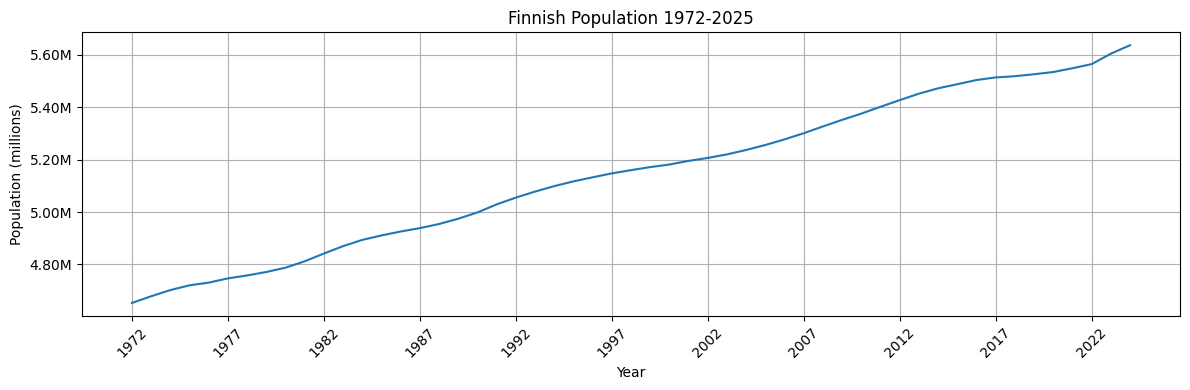

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ov_modern["Year"], ov_modern["population"]) # using Year and Population from population_overview.csv

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M")) # Formating scale to millions

plt.grid(True)
ax.set_xlabel("Year")
ax.set_ylabel("Population (millions)")
ax.set_title("Finnish Population 1972-2025")

ax.set_xticks(range(1972, 2025, 5))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

plt.show()

Data drawn on the graph are showing nonstoping increase Finnish population since 1972 with some fluctuation but without any visible decrease. Data drawn are preatty simple so they don't give much of a context of what this numbers stand for so I will try to take a closer look at rest of the information that I got.

### 2.2 Births vs Deaths in Finland 1972-2024

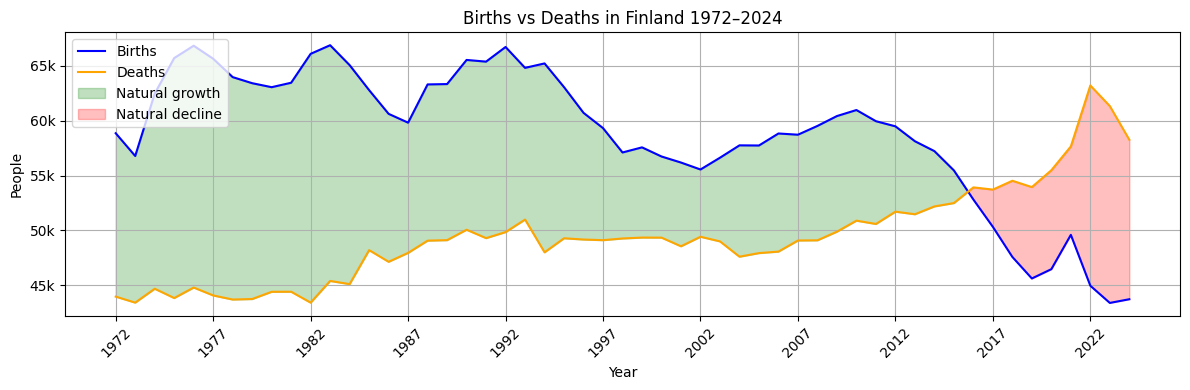

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ov_modern["Year"], ov_modern["births"], label="Births", color="blue"    ) # using Year, births and deaths from population_overview.csv
ax.plot(ov_modern["Year"], ov_modern["deaths"], label="Deaths", color="orange")

ax.fill_between(ov_modern["Year"], ov_modern["births"], ov_modern["deaths"],
                where=(ov_modern["births"] >= ov_modern["deaths"]),
                interpolate=True, alpha=0.25, color="green", label="Natural growth")

ax.fill_between(ov_modern["Year"], ov_modern["births"], ov_modern["deaths"],
                where=(ov_modern["births"] < ov_modern["deaths"]),
                interpolate=True, alpha=0.25, color="red", label="Natural decline")

plt.grid(True)
ax.set_xlabel("Year")
ax.set_ylabel("People")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.set_title("Births vs Deaths in Finland 1972–2024")

ax.set_xticks(range(1972, 2025, 5))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
plt.tight_layout()

plt.show()

This graph is showing us that in fact even though the Finnish poulation is growing in Finland people, since around 2016, more commonly die then they are born which stands in conflict with population growth. On the graph we can see that throughout the years moratility rate is growing probably becasue of growing population but more importantly the birth rate is significatly droping since around 2009 which is counter intuitive as bigger population should have bigger capacity to give birth.

### 2.3 Migration

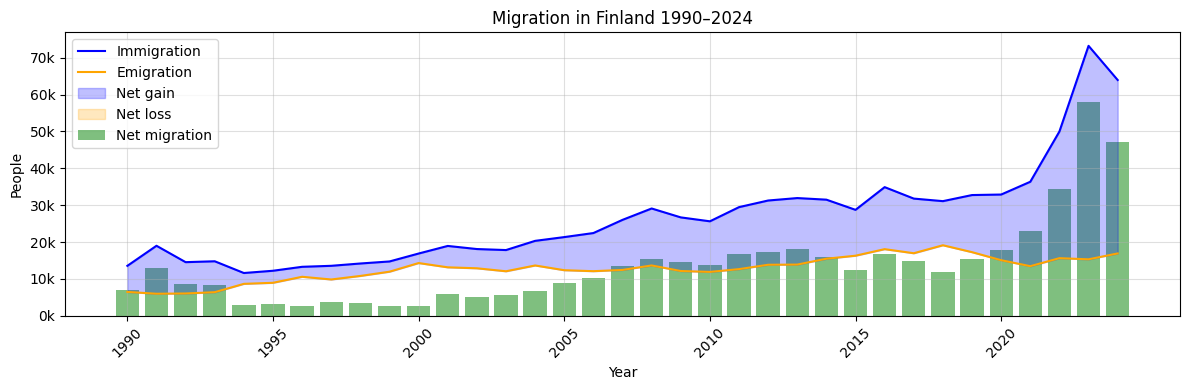

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(ov_migration["Year"], ov_migration["net_migration"], alpha=0.5, color="green", label="Net migration")

ax.plot(ov_migration["Year"], ov_migration["immigration"], label="Immigration", color="blue")
ax.plot(ov_migration["Year"], ov_migration["emigration"], label="Emigration", color="orange")

# Fill between immigration and emigration
ax.fill_between(ov_migration["Year"], ov_migration["immigration"], ov_migration["emigration"],
                where=(ov_migration["immigration"] >= ov_migration["emigration"]),
                interpolate=True, alpha=0.25, color="blue", label="Net gain")
ax.fill_between(ov_migration["Year"], ov_migration["immigration"], ov_migration["emigration"],
                where=(ov_migration["immigration"] < ov_migration["emigration"]),
                interpolate=True, alpha=0.25, color="orange", label="Net loss")

plt.grid(True, alpha=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("People")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.set_title("Migration in Finland 1990–2024")
ax.set_xticks(range(1990, 2025, 5))
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

The graphs shows that immigration is increasing steadly in Finland since year 2000. The increase of immigration was very steady since around 2007 but there is significant increase after the 2020s. I would expect bigger wave of immigration around year 2015 as Ukrainian war started but maybe the recent immigration wave after 2020s is just delayed indication of this event.

### 2.4 Births vs Deaths in comparison to migration

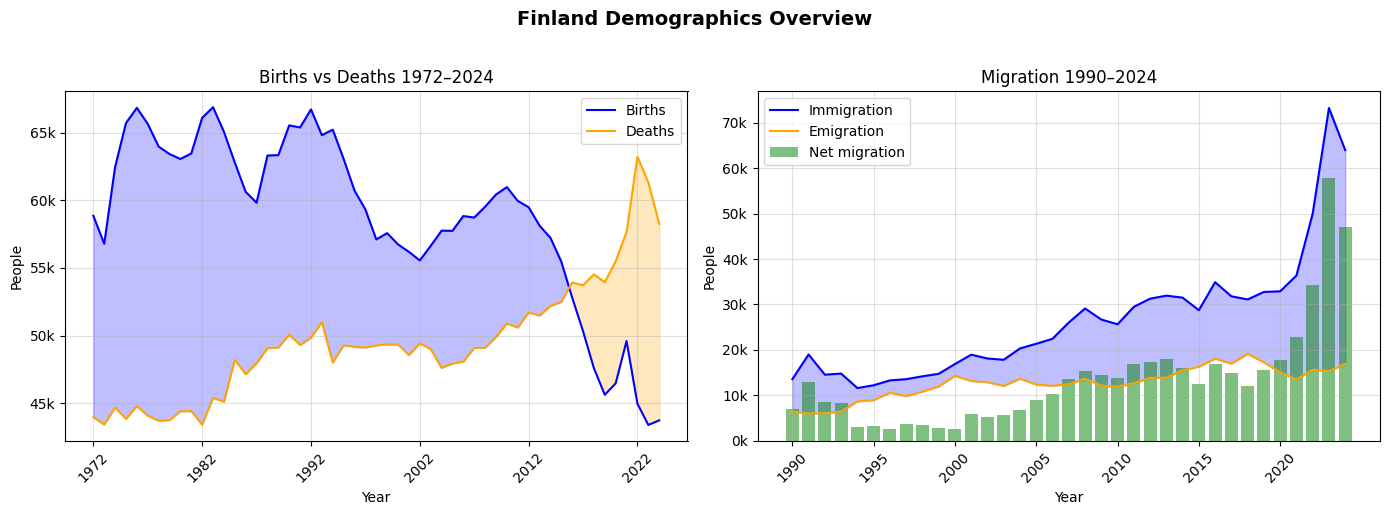

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Births vs Deaths ────────────────────────────────────────────
ax = axes[0]
ax.plot(ov_modern["Year"], ov_modern["births"], label="Births", color="blue")
ax.plot(ov_modern["Year"], ov_modern["deaths"], label="Deaths", color="orange")
ax.fill_between(ov_modern["Year"], ov_modern["births"], ov_modern["deaths"],
                where=(ov_modern["births"] >= ov_modern["deaths"]),
                interpolate=True, alpha=0.25, color="blue")
ax.fill_between(ov_modern["Year"], ov_modern["births"], ov_modern["deaths"],
                where=(ov_modern["births"] < ov_modern["deaths"]),
                interpolate=True, alpha=0.25, color="orange")
ax.set_title("Births vs Deaths 1972–2024")
ax.set_xlabel("Year")
ax.set_ylabel("People")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.set_xticks(range(1972, 2025, 10))
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(True, alpha=0.4)

# ── Panel 2: Migration ───────────────────────────────────────────────────
ax = axes[1]
ax.plot(ov_migration["Year"], ov_migration["immigration"], label="Immigration", color="blue")
ax.plot(ov_migration["Year"], ov_migration["emigration"], label="Emigration", color="orange")
ax.fill_between(ov_migration["Year"], ov_migration["immigration"], ov_migration["emigration"],
                where=(ov_migration["immigration"] >= ov_migration["emigration"]),
                interpolate=True, alpha=0.25, color="blue")
ax.fill_between(ov_migration["Year"], ov_migration["immigration"], ov_migration["emigration"],
                where=(ov_migration["immigration"] < ov_migration["emigration"]),
                interpolate=True, alpha=0.25, color="orange")
ax.bar(ov_migration["Year"], ov_migration["net_migration"], alpha=0.5, color="green", label="Net migration")
ax.set_title("Migration 1990–2024")
ax.set_xlabel("Year")
ax.set_ylabel("People")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.set_xticks(range(1990, 2025, 5))
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(True, alpha=0.4)

fig.suptitle("Finland Demographics Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Showing this graphs side by side I can notice that not long after the births rate droped below death rate the immigration if Finland exploded. This can explain why on population graph there was no clear indication that natural net growth of population is in the decline as immigration recompensated it. Very intresing thing is the spike visible clearly on both of the graphs the spikes are in very close proximity to each other, brith spike is shown in 2021 and death spike is visible at 2022, are showing big increase of immigration, death rade as well as birth rate which is very intresting but I don't have any theory about that it does seem like some kind of error but i highly doubt it as it is present in not direclty related data.

P.S. I mentioned the spike it could be COVID-19 aftermath. The spike in birth rate is called "post pandemic baby boom". When it comes to mortality spike I do think it is related to COVID-19 but I don't know much more then that. When it comes to migration spike it is probably caused of COVID-19 and opeining borders and prior start of war in 2014.

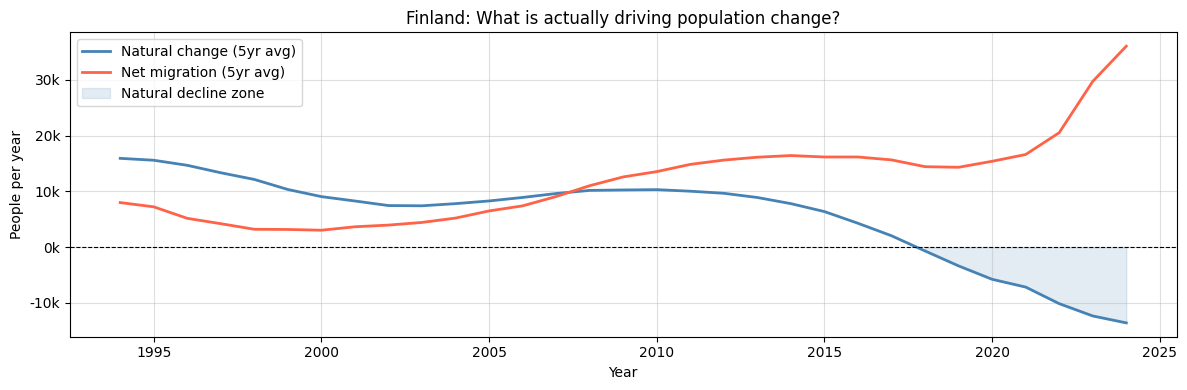

In [20]:
# Build ov_model from scratch
key_cols = ["population", "births", "deaths", "net_migration", "tfr"]
ov_model = ov.dropna(subset=key_cols).copy().sort_values("Year").reset_index(drop=True)
ov_model["natural_change"] = ov_model["births"] - ov_model["deaths"]

# ── Plot ───────────────────────────────────────────────────────────────────────
roll = ov_model.set_index("Year")[["natural_change", "net_migration"]].rolling(5).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll.index, roll["natural_change"], label="Natural change (5yr avg)", color="steelblue", linewidth=2)
ax.plot(roll.index, roll["net_migration"],  label="Net migration (5yr avg)",  color="tomato",    linewidth=2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(roll.index, roll["natural_change"], 0,
                where=(roll["natural_change"] < 0), alpha=0.15, color="steelblue", label="Natural decline zone")
ax.set_title("Finland: What is actually driving population change?")
ax.set_xlabel("Year")
ax.set_ylabel("People per year")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

This graph is showing the rising dependence on immigration very clearly. The migration overpassed natural growth of population before natural growth became negative values.

### 2.5 Total fertility rate in Finland

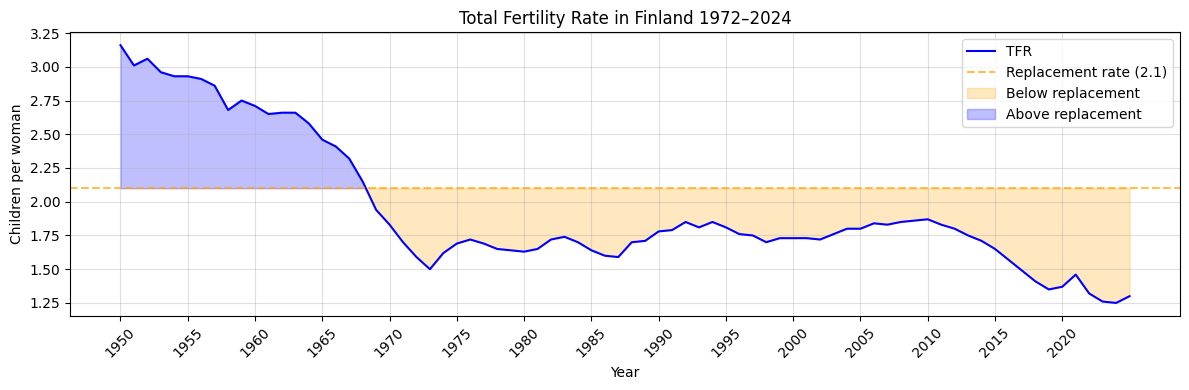

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(ov_tfr["Year"], ov_tfr["tfr"], color="blue", label="TFR")

# Shade below replacement rate (2.1)
ax.axhline(2.1, linestyle="--", color="orange", alpha=0.7, label="Replacement rate (2.1)")
ax.fill_between(ov_tfr["Year"], ov_tfr["tfr"], 2.1,
                where=(ov_tfr["tfr"] < 2.1),
                interpolate=True, alpha=0.25, color="orange", label="Below replacement")
ax.fill_between(ov_tfr["Year"], ov_tfr["tfr"], 2.1,
                where=(ov_tfr["tfr"] >= 2.1),
                interpolate=True, alpha=0.25, color="blue", label="Above replacement")

ax.set_title("Total Fertility Rate in Finland 1972–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Children per woman")
ax.set_xticks(range(1950, 2025, 5))
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

The previous graph was comparing births to deaths ratio which may not give away all that there is to these numbers. Fertility rate is illustrating how much of previous mentiont reproduction capacity population is using. TFR above 2 is saying that statistical women is giving birth to more then 2 children which says that she and her partner are contributing to the population as 2 children are promising replacment but no increase of population. No matter how big population is Fertility rate will always show used reproductive capacity which gives attitional context to raw births within the years. Said that I can see that around 1969 fertility rate droped below 2 which is saying that since at least 1970 finnish population is not even sustaining the population but is shrinking. It is visible as well that after 2020 the fertility rate is keepin the same trend which says that immigration is not influencing TFR which is surprising for me as I thought that immigrants do have more children, but as data shows it is not true.

### 2.6 Average age in Finland

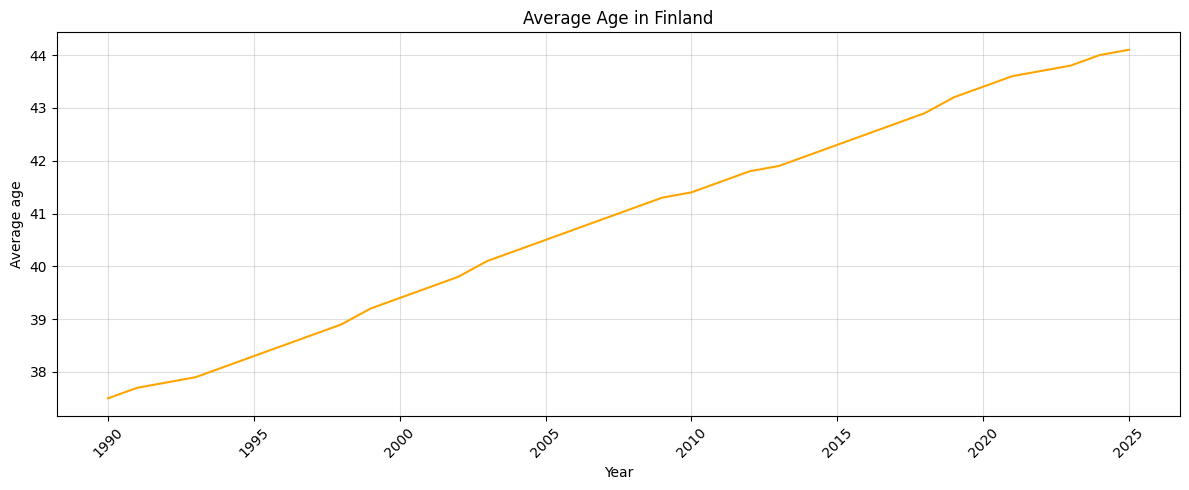

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

finland = reg[reg["Area"] == "WHOLE COUNTRY"]
ax.plot(finland["Year"], finland["avg_age_total"], color="orange")

ax.set_title("Average Age in Finland")
ax.set_xlabel("Year")
ax.set_ylabel("Average age")
ax.grid(True, alpha=0.4)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The graphs shows that statistical Fin is getting older every year the graph looks nearly like linear function streching from corner to corner of the plain with small inregularities. Every 5 years average of age is increasing for around half of a year which may sounds like not the big issue but in fact is very significant, as older societies have limited reproductive possibilites and do put more pressure on younger citizens. In comparison to the previous graphs I can say that population decrease problem of Finnish society is a cascade problem that started long before I have been born, but is starting to show the consequences relativly recently.

### 2.7 Urban share in Finland

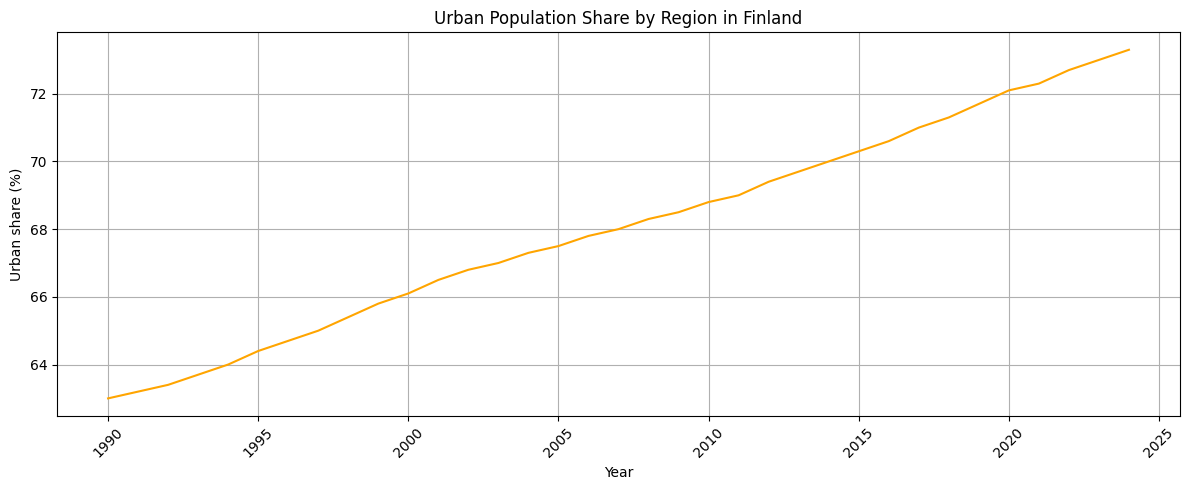

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

# Highlight Finland overall
finland = reg[reg["Area"] == "WHOLE COUNTRY"]
ax.plot(finland["Year"], finland["share_urban_pct"], color="orange")

ax.set_title("Urban Population Share by Region in Finland")
ax.set_xlabel("Year")
ax.set_ylabel("Urban share (%)")
ax.grid(True)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

On the graph I can see that Finland follows global trend of urbanization. I need to admit that I haven't had any clue how much Finland is and was urbanized.

## 3. Predicting the population for 2040

### 3.1 Extracting relevant factors

In [24]:
# ── 2.5.3  Derived rates ──────────────────────────────────────────────────────
ov_model = ov_migration.copy()

ov_model["birth_rate"] = ov_model["births"] / ov_model["population"] * 1000
ov_model["death_rate"] = ov_model["deaths"] / ov_model["population"] * 1000
ov_model["net_mig_rate"] = ov_model["net_migration"] / ov_model["population"] * 1000

print(ov_model[["Year", "birth_rate", "death_rate",
                "net_mig_rate", ]].tail(10).to_string(index=False))

 Year  birth_rate  death_rate  net_mig_rate
 2015   10.109146    9.566075      2.267232
 2016    9.596793    9.798308      3.056895
 2017    9.127483    9.744374      2.688854
 2018    8.622272    9.881805      2.168390
 2019    8.255310    9.764009      2.804377
 2020    8.396230   10.027119      3.219130
 2021    8.938689   10.392303      4.128335
 2022    8.078944   11.362211      6.175986
 2023    7.741641   10.945866     10.334679
 2024    7.757315   10.338414      8.348162


In this cell im creating dataframe ov_model which is ov_migration enrichend with birth_rate, death_rate, net_mig_rate

### 3.2 Recap of components used for forecasting

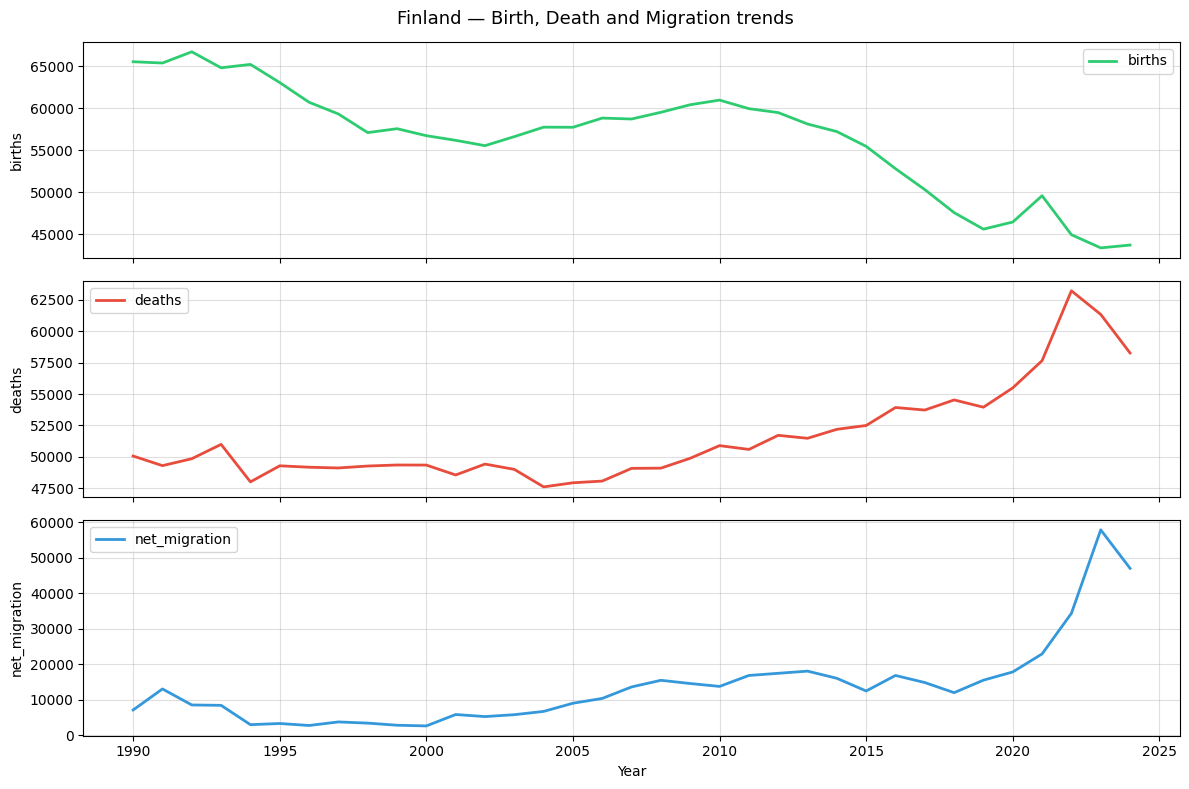

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

components = ['births', 'deaths', 'net_migration']
colors     = ['#2ecc71', '#e74c3c', '#3498db']

for ax, col, color in zip(axes, components, colors):
    ax.plot(ov_model['Year'], ov_model[col], color=color, linewidth=2, label=col)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.4)
    ax.legend()

axes[-1].set_xlabel('Year')
plt.suptitle('Finland — Birth, Death and Migration trends', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Births forecast

Births trend: -1,373 per year


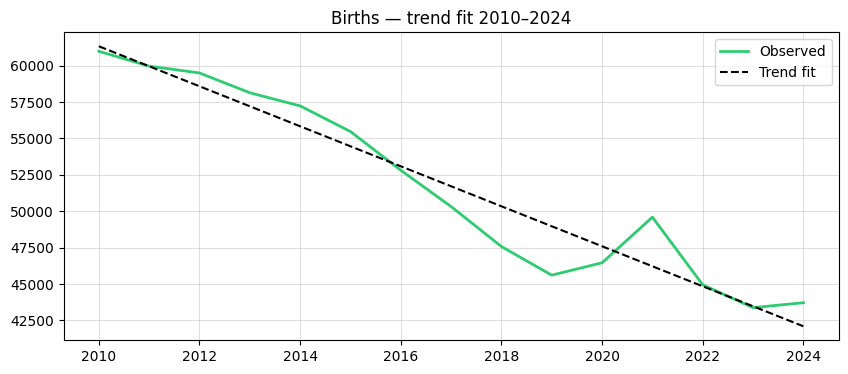

In [26]:
recent = ov_model[ov_model['Year'] >= 2010].copy()

# Fit linear trend to births
births_coeffs = np.polyfit(recent['Year'], recent['births'], 1)
births_trend  = np.poly1d(births_coeffs)

print(f"Births trend: {births_coeffs[0]:,.0f} per year")

# Plot to check the fit
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(recent['Year'], recent['births'], color='#2ecc71', linewidth=2, label='Observed')
ax.plot(recent['Year'], births_trend(recent['Year']), 'k--', label='Trend fit')
ax.set_title('Births — trend fit 2010–2024')
ax.legend()
ax.grid(True, alpha=0.4)
plt.show()

I used data from 2010 onwards as they show more consistency then the whole data, which by looking at the graph encrease coverage of linear function of the trend.

### 3.4 Deaths forecast

Deaths trend: +645 per year


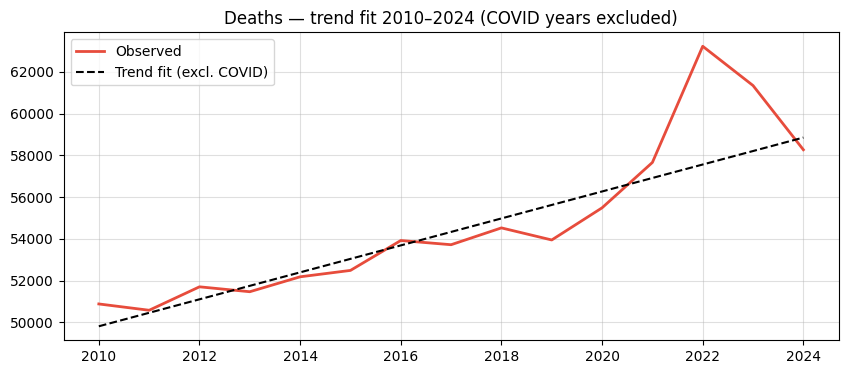

In [27]:
recent_deaths = recent[~recent['Year'].isin([2021, 2022])].copy()

deaths_coeffs = np.polyfit(recent_deaths['Year'], recent_deaths['deaths'], 1)
deaths_trend  = np.poly1d(deaths_coeffs)

print(f"Deaths trend: +{deaths_coeffs[0]:,.0f} per year")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(recent['Year'], recent['deaths'], color='#e74c3c', linewidth=2, label='Observed')
ax.plot(recent_deaths['Year'], deaths_trend(recent_deaths['Year']), 'k--', label='Trend fit (excl. COVID)')
ax.set_title('Deaths — trend fit 2010–2024 (COVID years excluded)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.show()

In Deaths case the after COVID-19 spike is ignored by linear regresion but looking at the 2024 we can assume that the trend line should come back to be correct.

### 3.5 Migration forecast

Migration trend: +4,505 per year


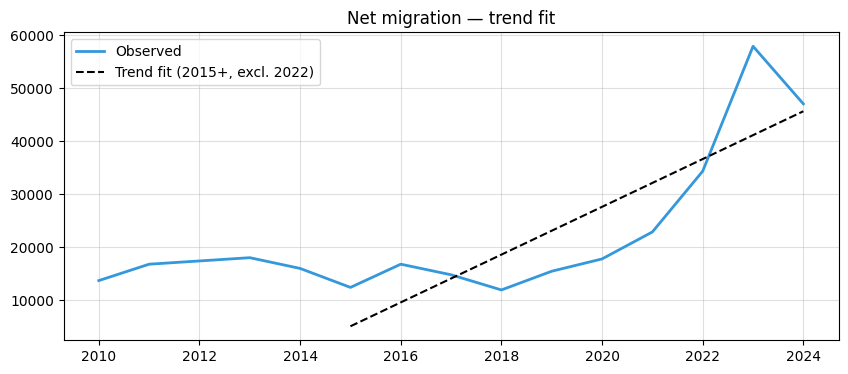

In [28]:
# Exclude 2022 spike, use 2015+ where upward trend begins
recent_mig = recent[(recent['Year'] >= 2015) & (~recent['Year'].isin([2022]))].copy()

mig_coeffs = np.polyfit(recent_mig['Year'], recent_mig['net_migration'], 1)
mig_trend  = np.poly1d(mig_coeffs)

print(f"Migration trend: +{mig_coeffs[0]:,.0f} per year")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(recent['Year'], recent['net_migration'], color='#3498db', linewidth=2, label='Observed')
ax.plot(recent_mig['Year'], mig_trend(recent_mig['Year']), 'k--', label='Trend fit (2015+, excl. 2022)')
ax.set_title('Net migration — trend fit')
ax.legend()
ax.grid(True, alpha=0.4)
plt.show()

The year 2022 is excluded from the prediction as it looks like outliner I am using data from 2015 as they show the biggest consistency.

### 3.6 Population forecast

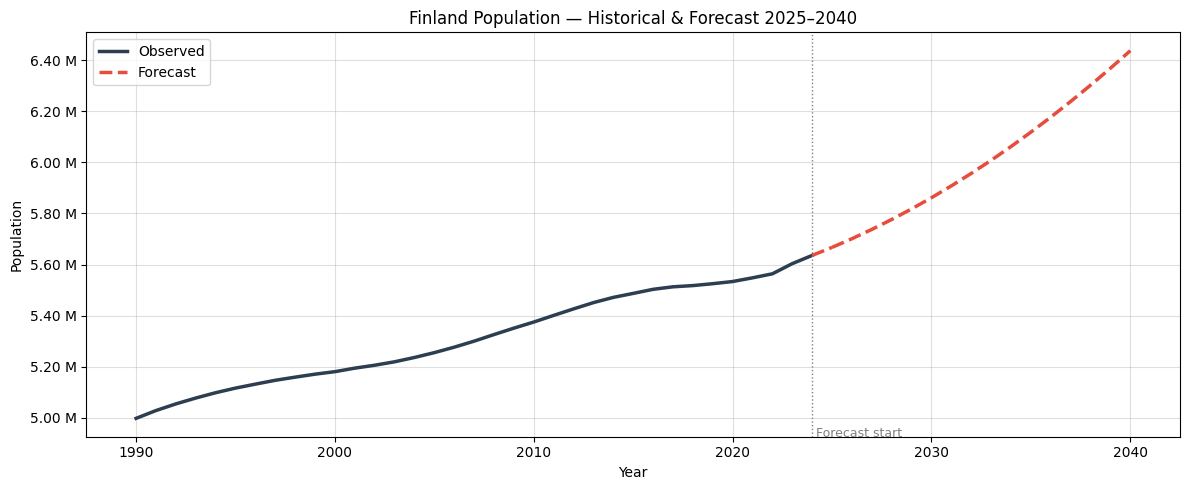

In [29]:
forecast_years = np.arange(2025, 2041)

# Project each component using the trend lines
projected_births    = births_trend(forecast_years)
projected_deaths    = deaths_trend(forecast_years)
projected_migration = mig_trend(forecast_years)

# Build population year by year
start_pop   = ov_model[ov_model['Year'] == 2024]['population'].values[0]
populations = [start_pop]

for i in range(len(forecast_years)):
    next_pop = populations[-1] + projected_births[i] - projected_deaths[i] + projected_migration[i]
    populations.append(next_pop)

# Remove the starting 2024 value
populations = populations[1:]

forecast_df = pd.DataFrame({
    'Year'          : forecast_years,
    'population'    : populations,
    'births'        : projected_births,
    'deaths'        : projected_deaths,
    'net_migration' : projected_migration,
})

fig, ax = plt.subplots(figsize=(12, 5))

# Historical
ax.plot(ov_model['Year'], ov_model['population'], 
        color='#2c3e50', linewidth=2.5, label='Observed')

# Forecast
ax.plot(forecast_df['Year'], forecast_df['population'], 
        color='#e74c3c', linewidth=2.5, linestyle='--', label='Forecast')

# Connect the two lines at 2024
ax.plot([2024, 2025], 
        [ov_model[ov_model['Year']==2024]['population'].values[0], forecast_df['population'].iloc[0]],
        color='#e74c3c', linewidth=2.5, linestyle='--')

ax.axvline(2024, color='gray', linestyle=':', linewidth=1)
ax.text(2024.2, ax.get_ylim()[0], 'Forecast start', fontsize=9, color='gray')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f} M'))
ax.set_xlabel('Year')
ax.set_ylabel('Population')
ax.set_title('Finland Population — Historical & Forecast 2025–2040')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

This prediciton is optimistic as it assume that the migration trend is not going to slow down which is very unlikly keeping the immigration as high as it is today is going to be challanging and increasing it seems nearly impossible, but the prediction is assuming that the birth rate is going to decrease even more which can change in the future with bigger ease then increasing migration at predictect level. I should mention as well that death rate probably is going to accelerate beacuse of the ageing population, this may influence the population growth significantly. Even with this unceratinties I wouldn't ignore this prediction as even though is optimistic it is still possible.

## 4. Municipality clustering

### 4.1 Extracting relevent data

In [30]:
YEAR_START, YEAR_END = 2015, 2024

anchor = reg_clean[reg_clean['Year'].isin([YEAR_START, YEAR_END])].copy()

wide = anchor.pivot_table(index='Area', columns='Year', 
                          values=['population', 'share_over_65_pct', 'avg_age_total'])
wide.columns = ['_'.join(map(str, c)) for c in wide.columns]
wide = wide.reset_index().dropna()

wide['pop_growth_pct'] = ((wide['population_2024'] - wide['population_2015']) 
                          / wide['population_2015'] * 100)
wide['aging_rate']     = wide['share_over_65_pct_2024'] - wide['share_over_65_pct_2015']
wide['avg_age_2024']   = wide['avg_age_total_2024']

mig_anchor = reg_clean[reg_clean['Year'].isin([YEAR_START, YEAR_END])].copy()
mig_wide = mig_anchor.pivot_table(index='Area', columns='Year', values='share_15_64_pct')
mig_wide.columns = [f'share_15_64_{y}' for y in mig_wide.columns]
mig_wide = mig_wide.reset_index()

wide = wide.merge(mig_wide, on='Area', how='left')
wide['working_age_change'] = wide['share_15_64_2024'] - wide['share_15_64_2015']

# ── Remove regional aggregates ──────────────────────────────────────────
import re
agg_pattern = re.compile(r'^(FI|TK|SA|SK|YTA|HVA|VP)\d', re.IGNORECASE)
wide = wide[wide['population_2024'] < 500_000]
wide = wide[~wide['Area'].str.match(agg_pattern)]

wide = wide[~wide['Area'].str.match(r'^[A-Z]{2,4}\d', re.IGNORECASE)]
# ────────────────────────────────────────────────────────────────────────

print(f"Municipalities: {len(wide)}")
wide[['Area', 'pop_growth_pct', 'aging_rate', 'working_age_change', 'avg_age_2024']].head(10)

Municipalities: 307


,Area,pop_growth_pct,aging_rate,working_age_change,avg_age_2024
0,Akaa,-3.849088,4.8,-1.3,45.7
1,Alajärvi,-9.274435,7.0,-4.7,47.4
2,Alavieska,-10.308895,5.2,-3.2,44.7
3,Alavus,-10.494852,6.0,-4.1,47.2
4,Asikkala,-4.802703,6.4,-4.3,50.7
5,Askola,-8.875392,6.1,-1.6,44.5
6,Aura,-0.501756,6.5,-3.5,43.4
7,Brändö,-8.510638,5.7,-3.8,52.9
8,Eckerö,2.245989,5.4,-6.0,47.7
9,Enonkoski,-12.559403,5.2,-4.7,53.7


Following the migartions trends I focus on people in productive age as they migrate as a significant majority

### 4.2 Clustering

In [31]:
features = ['pop_growth_pct', 'aging_rate', 'working_age_change', 'avg_age_2024']

X = wide[features].copy()
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
wide['cluster'] = kmeans.fit_predict(X_scaled)

# Quick summary of each cluster
print(wide.groupby('cluster')[features].mean().round(2))
print("\nCluster sizes:")
print(wide['cluster'].value_counts().sort_index())

         pop_growth_pct  aging_rate  working_age_change  avg_age_2024
cluster                                                              
0                -14.12        9.47               -8.47         54.22
1                -11.11        6.80               -4.67         50.62
2                  6.76        2.95               -0.78         41.93
3                 -4.44        4.65               -2.41         46.31

Cluster sizes:
cluster
0     47
1    112
2     55
3     93
Name: count, dtype: int64


KMeans clustering based on the features

### 4.3 Graphs of clusters

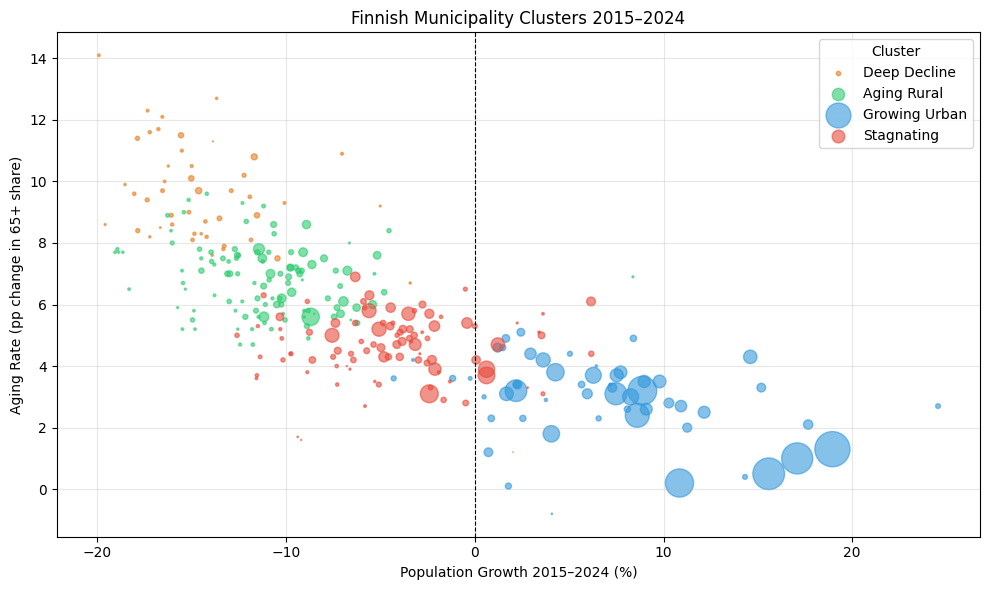

In [32]:
CLUSTER_NAMES = {
    0: 'Deep Decline',
    1: 'Aging Rural',
    2: 'Growing Urban',
    3: 'Stagnating'
}
CLUSTER_COLORS = {
    0: '#e67e22',
    1: '#2ecc71',
    2: '#3498db',
    3: '#e74c3c'
}

wide['cluster_name'] = wide['cluster'].map(CLUSTER_NAMES)

fig, ax = plt.subplots(figsize=(10, 6))

for c, group in wide.groupby('cluster'):
    ax.scatter(
        group['pop_growth_pct'],
        group['aging_rate'],
        s=group['population_2024'] / 500,  # size = population
        alpha=0.6,
        color=CLUSTER_COLORS[c],
        label=CLUSTER_NAMES[c]
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Population Growth 2015–2024 (%)')
ax.set_ylabel('Aging Rate (pp change in 65+ share)')
ax.set_title('Finnish Municipality Clusters 2015–2024')
ax.legend(title='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This graph represents shows the relation of aging rate and population growth in municipalities in Finland categorized by KMeans. At the graph we see that bigger in population areas that are more urbanized are growing in population. I can guess that they do attract migration as they keep relativly low agining rate comparing to others municipalities. I notices that the smollest areas are the oldest one and as brutal as it sounds it looks like this areas are moving out or dying off in favor of urbinized areas. One general observation majority of the municipalities are on the decline when it comes to population and they seem to be pretty old in comparison to singular big areas that are as an exception are growing and not aging that fast.

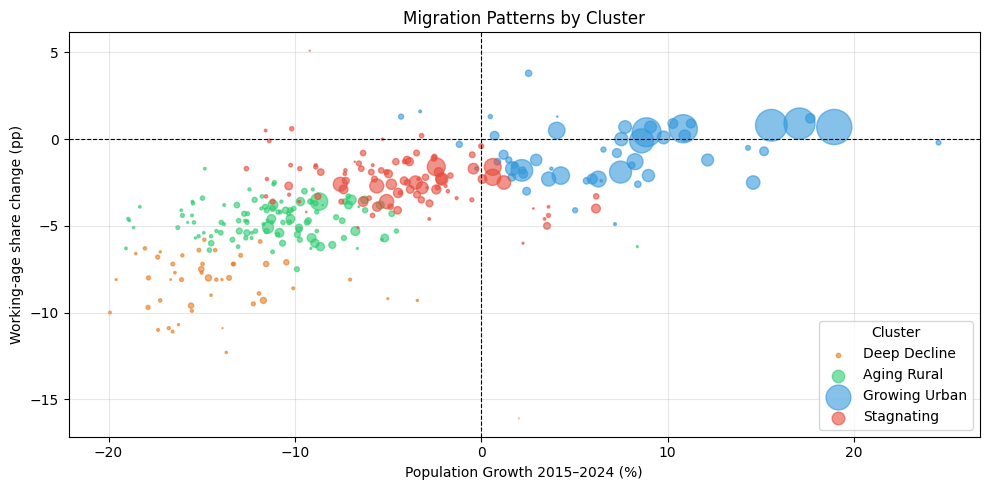

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

for c, group in wide.groupby('cluster'):
    ax.scatter(
        group['pop_growth_pct'],
        group['working_age_change'],
        s=group['population_2024'] / 500,
        alpha=0.6,
        color=CLUSTER_COLORS[c],
        label=CLUSTER_NAMES[c]
    )
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Population Growth 2015–2024 (%)')
ax.set_ylabel('Working-age share change (pp)')
ax.set_title('Migration Patterns by Cluster')
ax.legend(title='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This graph is showing relation between change of working age population of municipalities of Finland with population growth of these municipalities. On this graph it is clearly visible that people are moving out of smaller municipalities into the bigger ones. As finnish population is aging I need to adjust my reference point as even the areas that are atracting young people from diffrent regions can still get older in scale meaning they do take working-age citizen inside but people are still aging in bigger amounts that keeps them at negative values of working-age change. Considering that we can see that the most growing areas are in fact "welcoming" more people in "productive" age then they are aging which solidifies my assumntion of very intensive migrations to Urban areas.

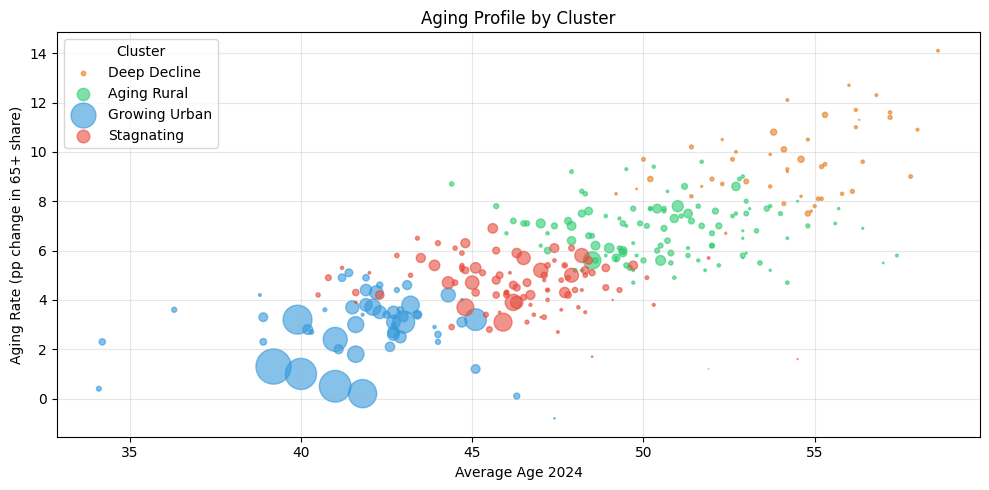

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

for c, group in wide.groupby('cluster'):
    ax.scatter(
        group['avg_age_2024'],
        group['aging_rate'],
        s=group['population_2024'] / 500,
        alpha=0.6,
        color=CLUSTER_COLORS[c],
        label=CLUSTER_NAMES[c]
    )
ax.set_xlabel('Average Age 2024')
ax.set_ylabel('Aging Rate (pp change in 65+ share)')
ax.set_title('Aging Profile by Cluster')
ax.legend(title='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This graph is showing the relation between increse of people older then 65 years old and average age in municipality. Here we can clearly see that nearly every area in Finland is getting older. Event growing urban areas are still aging. There is clear trend that the higher the average age is the aging is accelerating as well which is alarming as it means that municipalities in wors state are getting worst faster then before.

### 4.4 Top municipalities per cluster

In [35]:
cluster_table = (
    wide[['Area', 'cluster_name', 'population_2024', 'pop_growth_pct', 'aging_rate', 'avg_age_2024']]
    .sort_values(['cluster_name', 'population_2024'], ascending=[True, False])
)

print("── Top 5 municipalities per cluster ──\n")
for name, group in cluster_table.groupby('cluster_name'):
    print(f"  {name}  (n={len(group)})")
    display(
        group[['Area', 'population_2024', 'pop_growth_pct', 'aging_rate', 'avg_age_2024']]
        .head(5)
        .rename(columns={
            'population_2024':  'Population',
            'pop_growth_pct':   'Growth 2015–24 (%)',
            'aging_rate':       'Aging Rate (pp)',
            'avg_age_2024':     'Avg Age 2024'
        })
        .reset_index(drop=True)
    )
    print()

── Top 5 municipalities per cluster ──

  Aging Rural  (n=112)


,Area,Population,Growth 2015–24 (%),Aging Rate (pp),Avg Age 2024
0,Kouvola,78386.0,-8.699552,5.6,48.5
1,Savonlinna,31460.0,-11.437660,7.8,51.0
2,Imatra,24724.0,-11.176576,5.6,50.5
3,Sastamala,23464.0,-6.962728,6.1,49.0
4,Iisalmi,20463.0,-6.753247,7.1,47.0



  Deep Decline  (n=47)


,Area,Population,Growth 2015–24 (%),Aging Rate (pp),Avg Age 2024
0,Lieksa,10049.0,-14.636425,9.7,54.6
1,Kitee,9566.0,-11.687592,10.8,53.8
2,Kuhmo,7483.0,-15.023847,10.1,54.1
3,Pudasjärvi,7304.0,-11.541722,8.9,50.2
4,Suomussalmi,7038.0,-15.571017,11.5,55.3



  Growing Urban  (n=55)


,Area,Population,Growth 2015–24 (%),Aging Rate (pp),Avg Age 2024
0,Espoo,320931.0,18.950564,1.3,39.2
1,Tampere,260180.0,15.574943,0.5,41.0
2,Vantaa,251269.0,17.084411,1.0,40.0
3,Oulu,216152.0,8.878982,3.2,39.9
4,Turku,206073.0,10.846763,0.2,41.8



  Stagnating  (n=93)


,Area,Population,Growth 2015–24 (%),Aging Rate (pp),Avg Age 2024
0,Pori,83305.0,-2.410881,3.1,45.9
1,Lappeenranta,73327.0,0.620240,3.7,44.8
2,Hämeenlinna,68433.0,0.620488,3.9,46.2
3,Mikkeli,51890.0,-5.076374,5.2,47.0
4,Salo,50870.0,-5.604008,5.8,48.2


## 5. Conclusions

Finland's demographic data tells a coherent and concerning story across all three levels of analysis.

**Natural population change has turned negative.** Births have been falling since 2009 and crossed below deaths around 2016. The total fertility rate has been below the 2.1 replacement threshold since the late 1960s, meaning Finland has not been reproducing itself for over 50 years. The TFR continues to fall even after 2020, showing that recent immigration has not raised the national fertility rate.

**Immigration is now the only driver of national population growth.** Net migration has grown sharply and is the single factor keeping Finland's total population from declining. The linear trend projects net migration of roughly +50 000 per year by 2030, while the natural change (births minus deaths) is forecast to reach approximately −20 000 per year. Finland is becoming structurally dependent on immigration to sustain its population.

**Nearly every municipality is ageing — with no exceptions.** The K-Means clustering of 307 municipalities shows four distinct trajectories, but all four clusters share one thing: a rising 65+ share. Even the 55 Growing Urban municipalities (Helsinki, Tampere, Turku region) are ageing, just more slowly. The 47 Deep Decline municipalities — typically small, remote, and already old — are ageing fastest and shrinking fastest simultaneously, creating a compounding problem.

**The regional divide is widening.** Working-age population is draining from rural areas into urban centres. This erodes the tax base and service capacity of exactly the municipalities least able to attract new residents.

### So what?

The data points to several practical implications across policy and planning:

**Population & immigration policy**
Immigration policy is now effectively population policy. Without sustained high net migration, Finland's population will shrink within this decade.

**Employment trends**
The working-age share (15–64) is falling in every cluster, most sharply in Deep Decline (−8.5 pp since 2015) and Aging Rural (−4.7 pp). This means labour shortages will not arrive uniformly — rural municipalities and industries concentrated outside urban centres will face workforce gaps significantly earlier than cities. Sectors like healthcare, construction, and agriculture, which are already overrepresented in rural areas, are most exposed.

**School capacity planning**
Falling birth rates and youth population drain point in the same direction: fewer children. Municipalities in the Deep Decline and Aging Rural clusters are already seeing the under-15 share shrink. School consolidations and closures are likely unavoidable in these areas, while Growing Urban municipalities may face the opposite pressure — insufficient classroom capacity as young families concentrate in cities.

**Housing market forecasting**
Population trajectories diverge sharply by cluster. Growing Urban areas will sustain housing demand, keeping prices elevated and new construction necessary. Deep Decline municipalities face the risk of a hollowing housing market — falling demand, depreciating property values, and an increasing share of vacant or abandoned stock. This has direct implications for municipal finances, as property tax bases erode alongside population.

**Regional differentiation**
All of the above underscore that a single national policy framework cannot address clusters with such different trajectories. Deep Decline municipalities losing significant part of their population over the years face existential planning challenges that are categorically different from those of growing urban areas.